# CNN

In [4]:
import os
import numpy as np
import torch
import pandas as pd
from plt_rcs import *

In [5]:
plt.rc(group='figure', figsize=(4, 4))

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='mps')

In [7]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [8]:
os.chdir('../../data')

In [9]:
[i for i in os.listdir() if i.startswith('MNIST')]

['MNIST', 'MNIST_Dataset.pkl']

In [10]:
objs = pd.read_pickle('MNIST_Dataset.pkl')

In [11]:
globals().update(objs)

In [12]:
%whos

Variable      Type      Data/Info
---------------------------------
device        device    mps
np            module    <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs          dict      n=2
os            module    <module 'os' (frozen)>
pd            module    <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt           module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns           module    <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
test_mnist    MNIST     Dataset MNIST\n    Number<...> std=0.308)\n           )
torch         module    <module 'torch' from '/op<...>kages/torch/__init__.py'>
train_mnist   MNIST     Dataset MNIST\n    Number<...> std=0.308)\n           )


In [13]:
test_mnist, train_mnist = test_mnist, train_mnist

In [14]:
os.chdir('../code/dl')

In [15]:
from trainer import Trainer, set_seed

In [16]:
set_seed(0)

In [17]:
from torch.utils.data import DataLoader

In [18]:
bs = 256

In [19]:
train_loader = DataLoader(train_mnist, batch_size=bs, shuffle=True)
test_loader = DataLoader(test_mnist, batch_size=bs, shuffle=False)

## 합성곱 신경망 모델 생성

In [20]:
import torch.nn as nn

- 첫 번째 합성곱 층의 필터는 (1, 3, 3)이고, 두 번째 합성곱 층의 필터는 (32, 3, 3)
- 각 합성곱 층의 필터는 각 32개씩 모인 집합

In [21]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=6272, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10)
).to(device)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [23]:
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    flatten=False # 합성곱 신경망의 입력은 평탄화 하지 않음
)

[Trainer] Using device: mps:0


In [24]:
history = trainer.fit(n_epochs=10)

[Epoch 01] Loss = 0.2069, Train_Acc = 0.9833, Test_Acc = 0.9820
[Epoch 02] Loss = 0.0483, Train_Acc = 0.9921, Test_Acc = 0.9865
[Epoch 03] Loss = 0.0312, Train_Acc = 0.9938, Test_Acc = 0.9860
[Epoch 04] Loss = 0.0220, Train_Acc = 0.9955, Test_Acc = 0.9879
[Epoch 05] Loss = 0.0143, Train_Acc = 0.9976, Test_Acc = 0.9888
[Epoch 06] Loss = 0.0086, Train_Acc = 0.9983, Test_Acc = 0.9888
[Epoch 07] Loss = 0.0073, Train_Acc = 0.9981, Test_Acc = 0.9881
[Epoch 08] Loss = 0.0076, Train_Acc = 0.9978, Test_Acc = 0.9879
[Epoch 09] Loss = 0.0062, Train_Acc = 0.9978, Test_Acc = 0.9864
[Epoch 10] Loss = 0.0050, Train_Acc = 0.9946, Test_Acc = 0.9856
Total training time: 0 min 51 sec


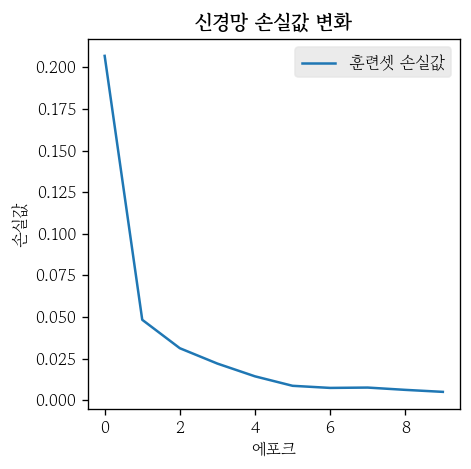

In [25]:
trainer.plot_loss()

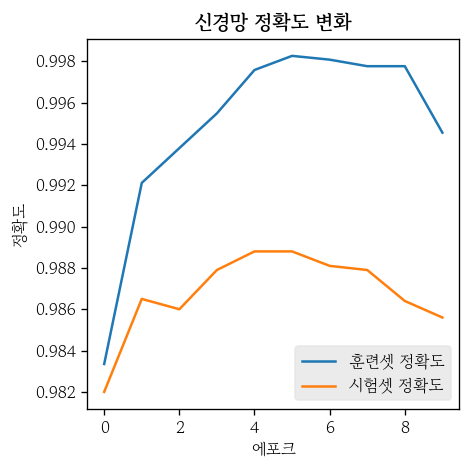

In [26]:
trainer.plot_accuracy()

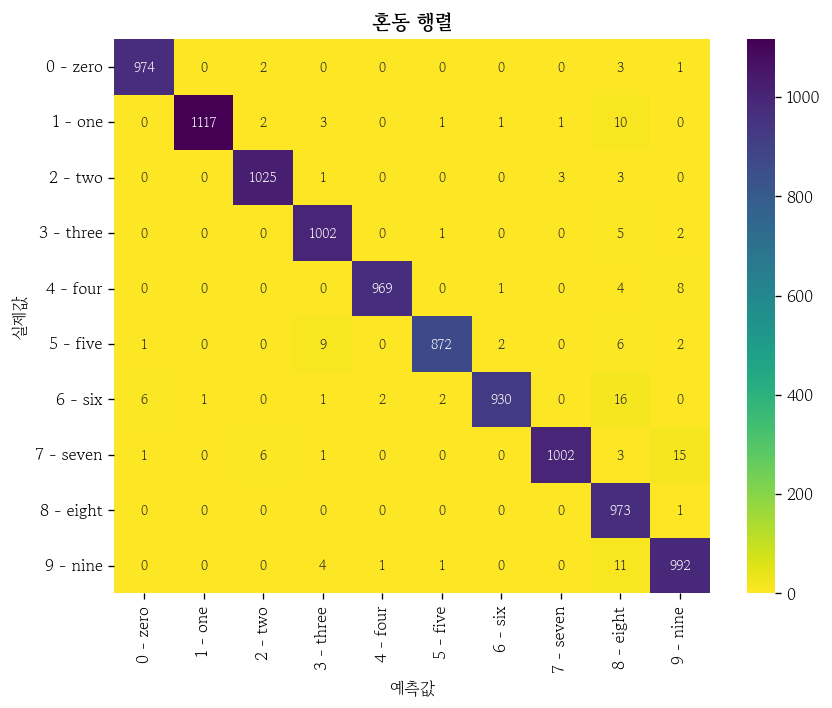

In [27]:
trainer.plot_confusion_matrix(data_loader=test_loader)

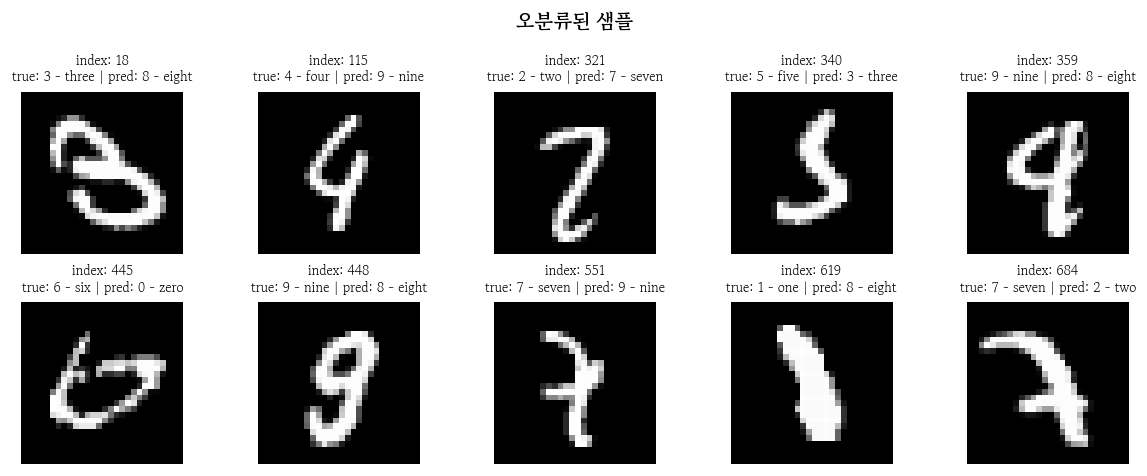

In [28]:
trainer.plot_misclassified(data_loader=test_loader)

## 오분류된 표본의 인덱스 생성

In [29]:
y_prob, y_pred, y_true = trainer.predict_loader(data_loader=test_loader)

In [30]:
mis_index = torch.where(y_true.ne(y_pred))[0]
mis_index[:10]

tensor([ 18, 115, 321, 340, 359, 445, 448, 551, 619, 684])

## Grad-CAM

- GradCAM 객체를 생성한 이후에는 모델 예측을 할 수 없으니 이전에 완료해야 함

In [31]:
from torchcam.methods import GradCAM

In [32]:
model.eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=6272, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=10, bias=True)
)

In [33]:
target_layer = model[2]

In [34]:
gradcam = GradCAM(model=model, target_layer=target_layer)

## 예측 클래스 기준 Grad-CAM 히트맵 시각화

In [56]:
index = mis_index[0]

In [57]:
image, label = test_mnist[index]

In [58]:
logits = model(image.unsqueeze(dim=0).to(device))

In [59]:
pred = logits.argmax(dim=1).item()

In [60]:
cam_pred = gradcam(class_idx=pred, scores=logits)

In [61]:
# 히트맵 제목에 추가할 실제값과 예측값의 타겟 범주 생성
true_label = test_mnist.classes[label]
pred_label = test_mnist.classes[pred]

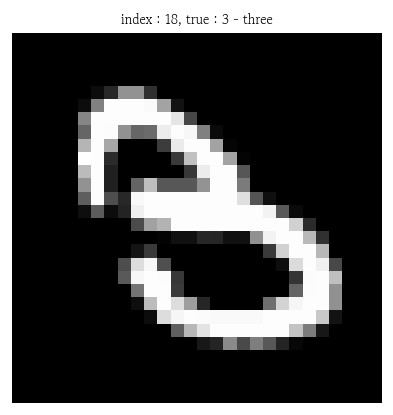

In [62]:
plt.imshow(X=image.squeeze(), cmap='gray')
plt.title(label=f'index : {index}, true : {true_label}', fontsize=8)
plt.axis('off')
plt.show()

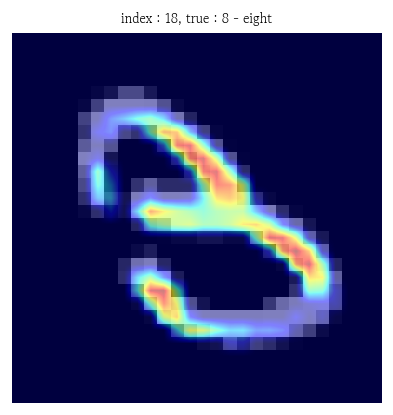

In [63]:
plt.imshow(X=image.squeeze(), cmap='gray')
plt.imshow(X=cam_pred[0].squeeze().cpu().numpy(), cmap='jet', interpolation='bilinear', alpha=0.5)
plt.title(label=f'index : {index}, true : {pred_label}', fontsize=8)
plt.axis('off')
plt.show()

## 실제 클래스 기준 Grad-CAM 히트맵 시각화

In [64]:
logits = model(image.unsqueeze(dim=0).to(device))

In [65]:
cam_true = gradcam(class_idx=label, scores=logits)

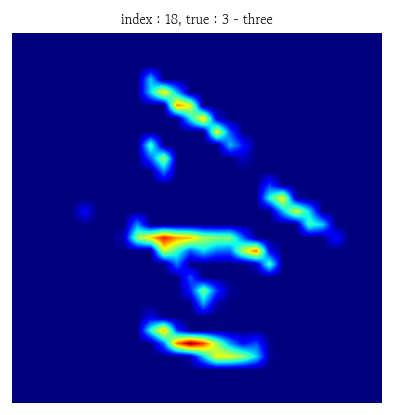

In [67]:
plt.imshow(X=cam_true[0].squeeze().cpu().numpy(), cmap='jet', interpolation='bilinear')
plt.title(label=f'index : {index}, true : {true_label}', fontsize=8)
plt.axis('off')
plt.show()

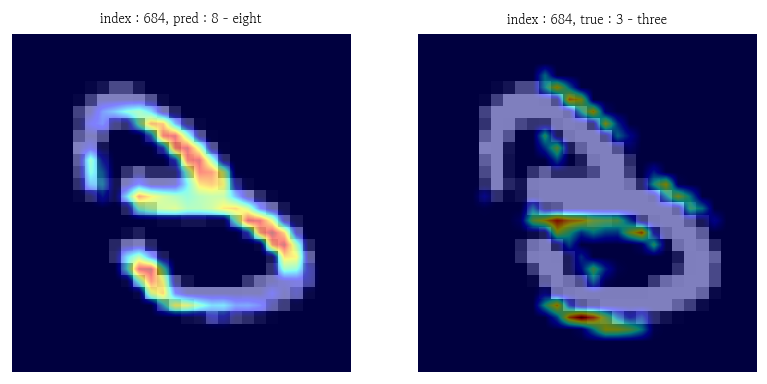

In [109]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].imshow(X=image.squeeze(), cmap='gray')
axes[0].imshow(X=cam_pred[0].squeeze().cpu().numpy(), cmap='jet', interpolation='bilinear', alpha=0.5)
axes[0].set_title(label=f'index : {index}, pred : {pred_label}', fontsize=8)
axes[0].axis('off')

axes[1].imshow(X=image.squeeze(), cmap='gray')
axes[1].imshow(X=cam_true[0].squeeze().cpu().numpy(), cmap='jet', interpolation='bilinear', alpha=0.5)
axes[1].set_title(label=f'index : {index}, true : {true_label}', fontsize=8)
axes[1].axis('off')

plt.show()

## Grad-CAM 시각화 함수 생성

In [83]:
def plot_gradcam_sample(dataset, index, model, gradcam, ax=None, cmap='jet', interpolation='bilinear'):
    image, label = dataset[index]
    image = image.to(device)
    logits = model(image.unsqueeze(dim=0))
    pred = logits.argmax(dim=1).item()
    cam_pred = gradcam(class_idx=pred, scores=logits)
    true_label = dataset.classes[label]
    pred_label = dataset.classes[pred]

    if ax is None:
        ax = plt.gca()
    
    ax.imshow(X=image.squeeze().detach().cpu(), cmap='gray')
    ax.imshow(X=cam_pred[0].squeeze().detach().cpu(), cmap=cmap, alpha=0.5, interpolation=interpolation)
    ax.set_title(f'index : {index}\ntrue : {true_label} | pred : {pred_label}')
    ax.axis('off')

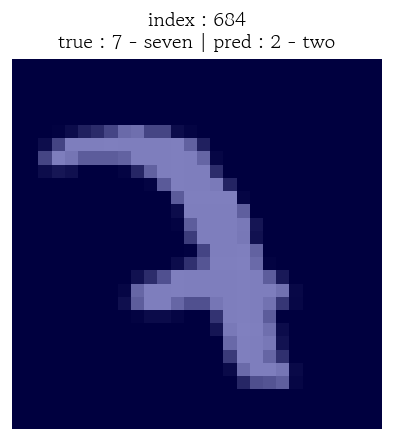

In [84]:
plot_gradcam_sample(dataset=test_mnist, index=index, model=model, gradcam=gradcam, ax=None)

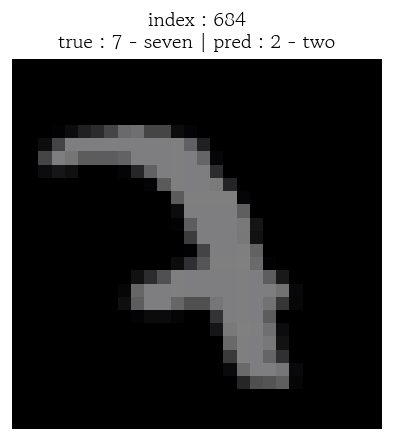

In [85]:
plot_gradcam_sample(dataset=test_mnist, index=index, model=model, gradcam=gradcam, ax=None, cmap='inferno', interpolation='bicubic')

## 여러 표본에 대한 Grad-CAM 히트맵 시각화

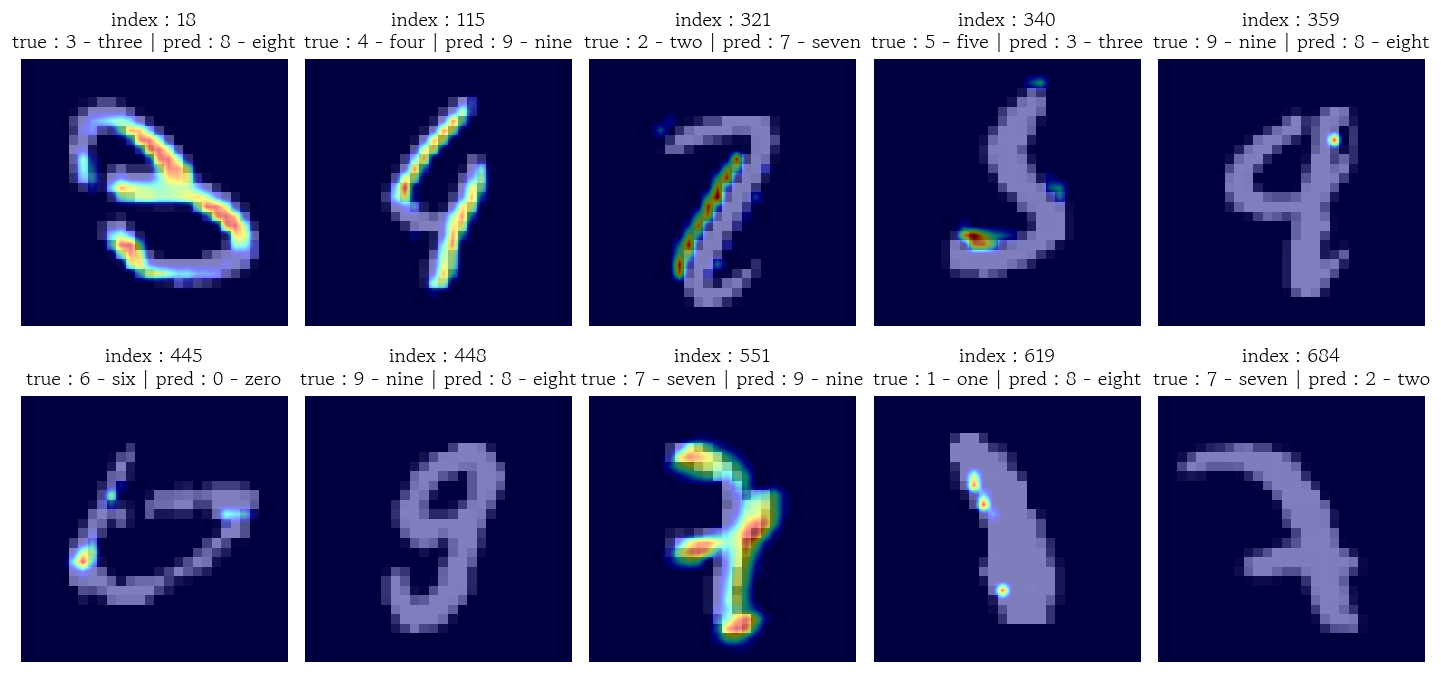

In [86]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
for ax, index in zip(axes.flatten(), mis_index[:10]): # axes 2차원 배열이기 때문에 flatten 필요
    plot_gradcam_sample(dataset=test_mnist, index=index.item(), model=model, gradcam=gradcam, ax=ax)
plt.tight_layout()
plt.show()

## 타겟 레이어에 등록된 hook 제거

In [ ]:
target_layer._forward_hooks
# OrderedDict([(0,
#               functools.partial(<bound method _CAM._hook_a of GradCAM(target_layer=['2'])>, idx=0)),
#              (1,
#               functools.partial(<bound method _GradCAM._hook_g of GradCAM(target_layer=['2'])>, idx=0))])

OrderedDict([(0,
              functools.partial(<bound method _CAM._hook_a of GradCAM(target_layer=['2'])>, idx=0)),
             (1,
              functools.partial(<bound method _GradCAM._hook_g of GradCAM(target_layer=['2'])>, idx=0))])

In [89]:
gradcam.remove_hooks()

In [ ]:
target_layer._forward_hooks
# OrderedDict()

OrderedDict()

In [ ]:
# 타겟 레이어의 forward hook과 backward hook을 제거하면 모델 예측이 가능해짐
# y_prob, y_pred, y_true = trainer.predict_loader(data_loader=test_loader)

## GradCAMViz 클래스 임포트

In [91]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [93]:
from gradcamviz import GradCAMViz

In [94]:
model.eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=6272, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=10, bias=True)
)

In [95]:
target_layer = model[2]

In [96]:
viewer = GradCAMViz(
    model=model,
    target_layer=target_layer,
    data_loader=test_loader
)

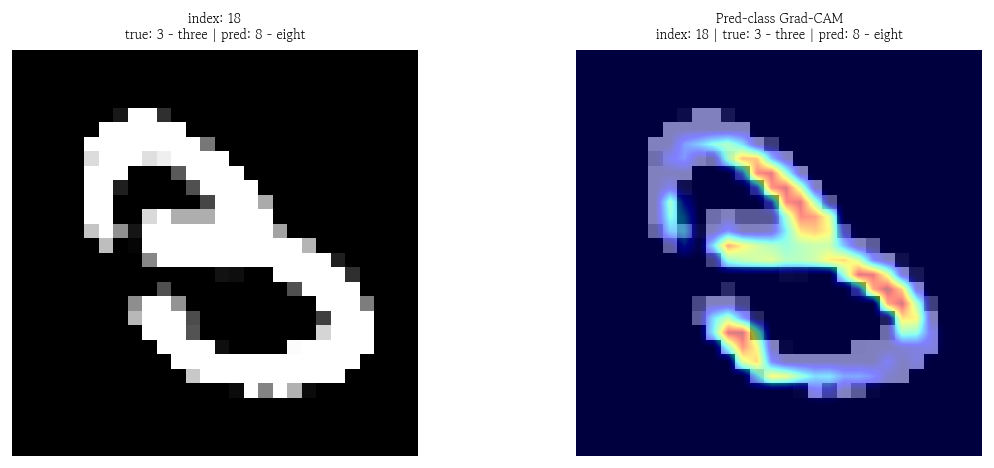

In [97]:
viewer.plot_sample(index=mis_index[0].item(), class_mode='pred');

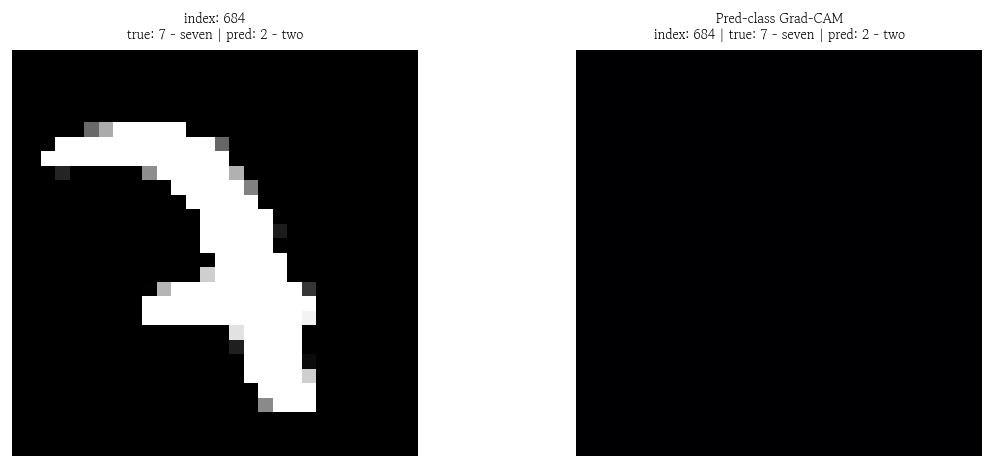

In [99]:
viewer.plot_sample(index=index, overlay=False, cmap='inferno', interpolation='bilinear');

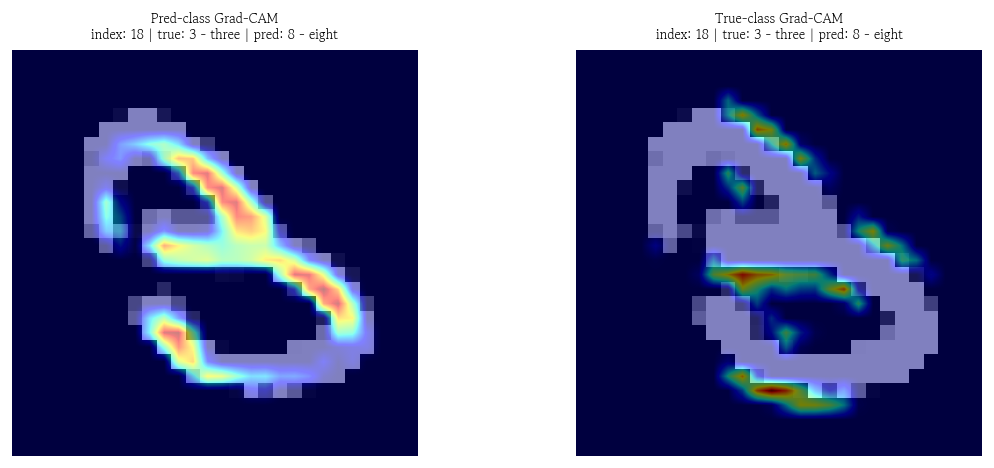

In [106]:
viewer.plot_pred_true_comparison(mis_index[0].item());

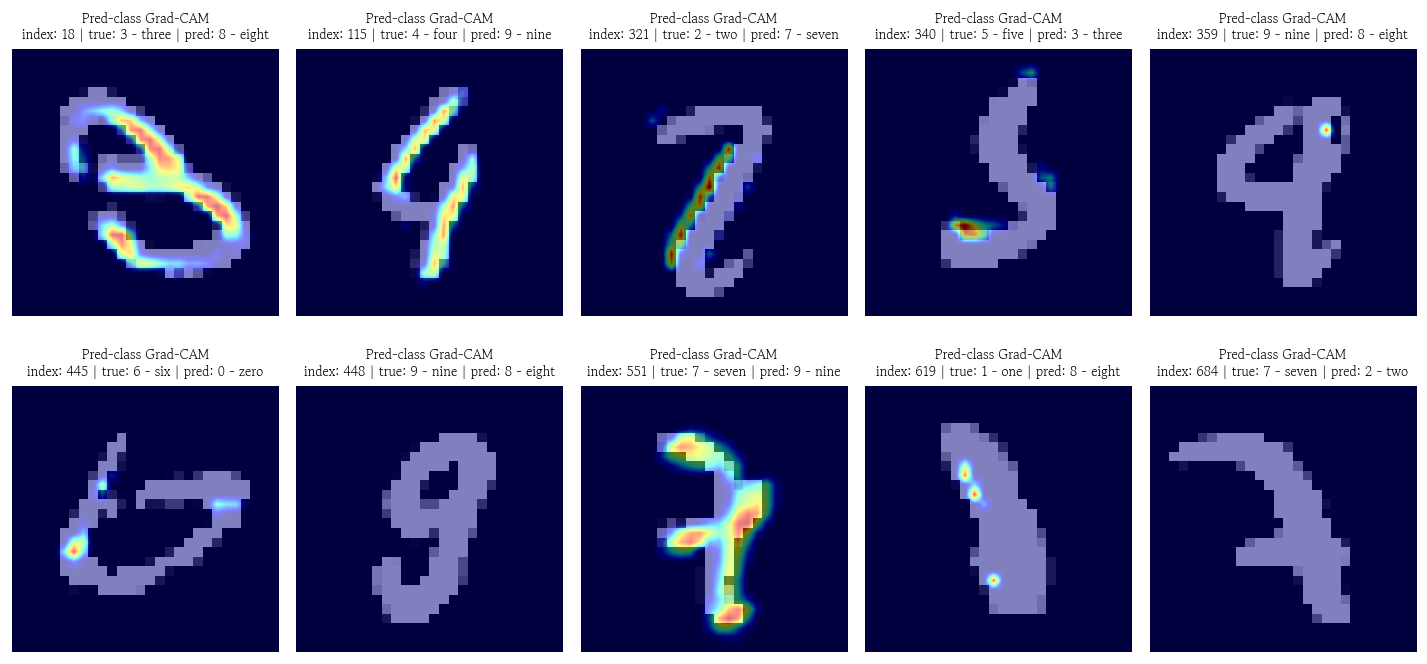

In [107]:
viewer.plot_multiple_samples(indices=mis_index[:10], nrows=2, ncols=5);

In [108]:
viewer.close()